<a href="https://colab.research.google.com/github/subhash068/Sales-Data-Analysis-Python/blob/main/Sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas matplotlib seaborn jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.3 MB/s eta 0:00:00


Shape: (2823, 25)
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Ab

/tmp/ipykernel_1760/389131000.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_sales.values, y=product_sales.index, palette='coolwarm')


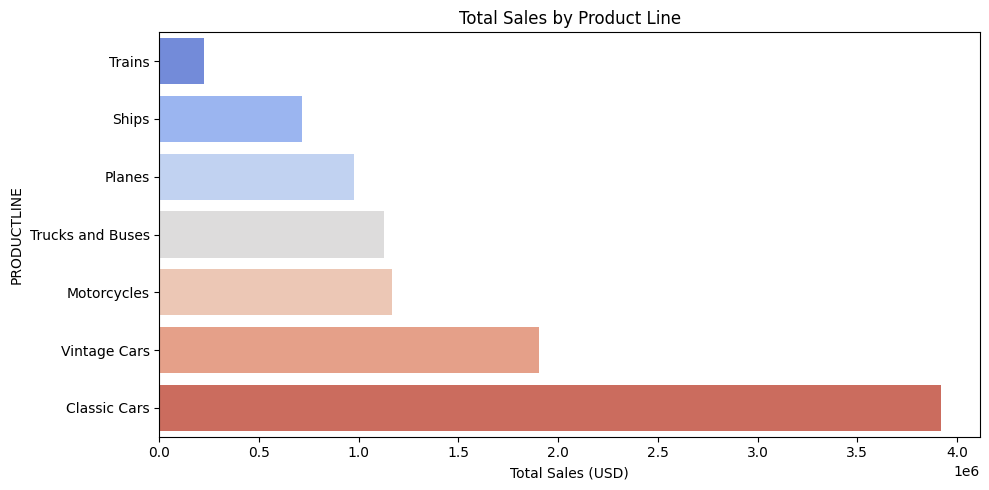

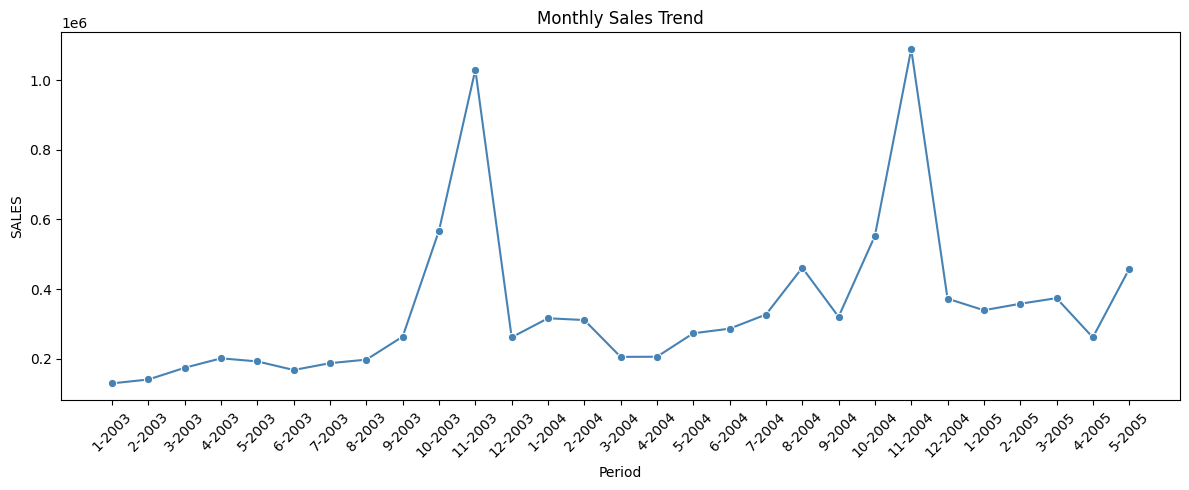

/tmp/ipykernel_1760/389131000.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette='viridis')


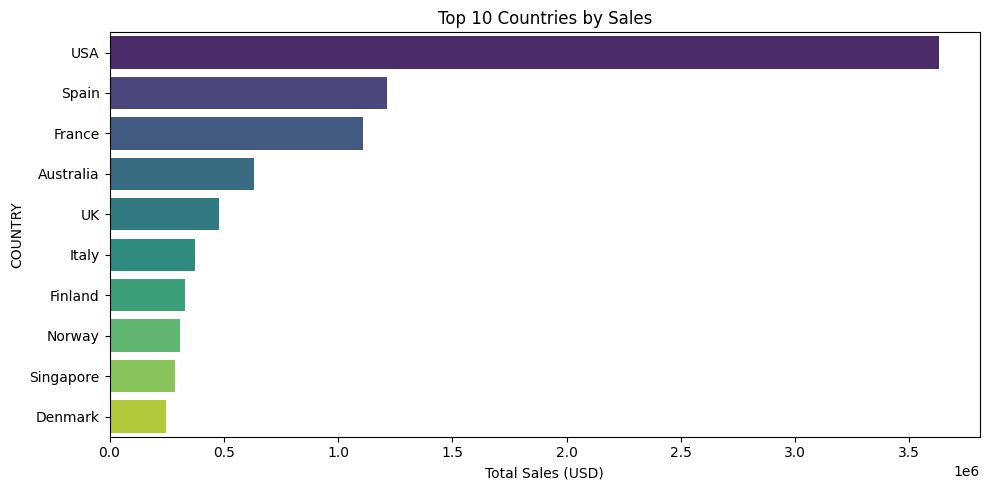

/tmp/ipykernel_1760/389131000.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DEALSIZE', palette='Set2',


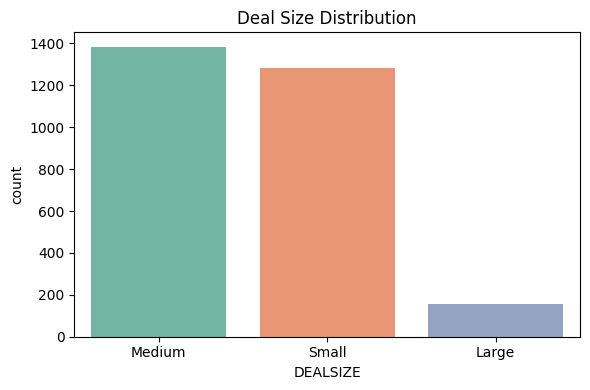


── Summary ──
Total Revenue: $ 10032628.85
Average Order Value: $ 3553.89
Best Product Line: Classic Cars
Top Country: USA


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. LOAD DATA ──────────────────────────────────────
df = pd.read_csv('sales_data_sample.csv', encoding='latin-1')
print("Shape:", df.shape)
print(df.head())

# ── 2. DATA CLEANING ──────────────────────────────────
print("\nMissing Values:\n", df.isnull().sum())
df.dropna(subset=['SALES', 'ORDERDATE', 'PRODUCTLINE'], inplace=True)
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
df['YEAR'] = df['ORDERDATE'].dt.year
df['MONTH'] = df['ORDERDATE'].dt.month

# ── 3. TOTAL SALES BY PRODUCT LINE ────────────────────
plt.figure(figsize=(10, 5))
product_sales = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values()
sns.barplot(x=product_sales.values, y=product_sales.index, palette='coolwarm')
plt.title('Total Sales by Product Line')
plt.xlabel('Total Sales (USD)')
plt.tight_layout()
plt.savefig('sales_by_product.png')
plt.show()

# ── 4. MONTHLY SALES TREND ────────────────────────────
plt.figure(figsize=(12, 5))
monthly = df.groupby(['YEAR', 'MONTH'])['SALES'].sum().reset_index()
monthly['Period'] = monthly['MONTH'].astype(str) + '-' + monthly['YEAR'].astype(str)
sns.lineplot(data=monthly, x='Period', y='SALES', marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

# ── 5. TOP 10 COUNTRIES BY SALES ──────────────────────
plt.figure(figsize=(10, 5))
country_sales = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=country_sales.values, y=country_sales.index, palette='viridis')
plt.title('Top 10 Countries by Sales')
plt.xlabel('Total Sales (USD)')
plt.tight_layout()
plt.savefig('country_sales.png')
plt.show()

# ── 6. DEAL SIZE DISTRIBUTION ─────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='DEALSIZE', palette='Set2',
              order=df['DEALSIZE'].value_counts().index)
plt.title('Deal Size Distribution')
plt.tight_layout()
plt.savefig('deal_size.png')
plt.show()

# ── 7. SUMMARY STATISTICS ─────────────────────────────
print("\n── Summary ──")
print("Total Revenue: $", round(df['SALES'].sum(), 2))
print("Average Order Value: $", round(df['SALES'].mean(), 2))
print("Best Product Line:", df.groupby('PRODUCTLINE')['SALES'].sum().idxmax())
print("Top Country:", df.groupby('COUNTRY')['SALES'].sum().idxmax())